## 1. SGD (Stochastic Gradient Descent)
* Definition: An optimization algorithm that updates parameters using the gradient computed from individual or mini-batch data samples.
* Use Cases:
    * Simple baseline models and online learning setups.
* Pros:
    * Computationally lightweight; noisy updates help escape shallow local minima.
* Cons:
    * Can oscillate wildly and get stuck in ravines due to a lack of adaptive step sizing.

### Visualizing SGD Path

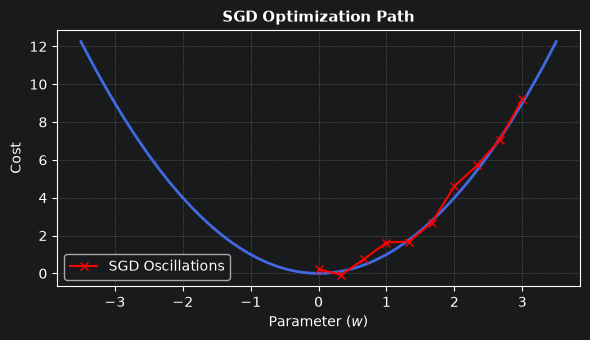

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
steps_w = np.linspace(3, 0, 10)
steps_cost = steps_w**2 + np.random.normal(0, 0.4, len(steps_w))

plt.figure(figsize=(6, 3.5))
w = np.linspace(-3.5, 3.5, 100)
plt.plot(w, w**2, color='royalblue', linewidth=2)
plt.plot(steps_w, steps_cost, marker='x', color='red', linewidth=1.5, label="SGD Oscillations")
plt.title("SGD Optimization Path", fontsize=11, fontweight='bold')
plt.xlabel("Parameter ($w$)")
plt.ylabel("Cost")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Momentum
* Definition: An extension of SGD that adds a fraction of the previous update vector to the current update, accumulating velocity.
* Use Cases:
    * Deep networks with complex error surfaces containing ravines or local plateaus.
* Pros:
    * Accelerates convergence in the correct direction and dampens erratic cross-oscillations.
* Cons:
    * Can overshoot optimal minima if momentum is set too high.

### Visualizing Momentum Damping Oscillations

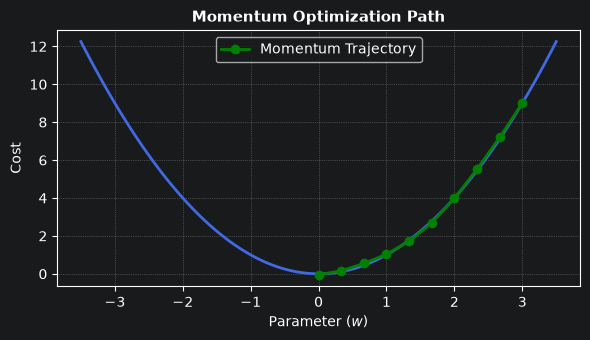

In [2]:
import numpy as np
import matplotlib.pyplot as plt

steps_w = np.linspace(3, 0, 10)
# Momentum smooths out oscillations
steps_cost = steps_w**2 + 0.1 * np.sin(np.linspace(0, 10, 10))

plt.figure(figsize=(6, 3.5))
w = np.linspace(-3.5, 3.5, 100)
plt.plot(w, w**2, color='royalblue', linewidth=2)
plt.plot(steps_w, steps_cost, marker='o', color='green', linewidth=2, label="Momentum Trajectory")
plt.title("Momentum Optimization Path", fontsize=11, fontweight='bold')
plt.xlabel("Parameter ($w$)")
plt.ylabel("Cost")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Nesterov Accelerated Gradient (NAG)
* Definition: A modification of momentum that calculates the gradient not at the current position, but at the anticipated future position.
* Use Cases:
    * Deep learning models requiring smarter, predictive deceleration before reaching minima.
* Pros:
    * Provides a "look-ahead" capability that prevents overshooting and improves convergence stability.
* Cons:
    * Slightly more complex to compute than standard momentum.

### Visualizing Nesterov Look-Ahead Concept

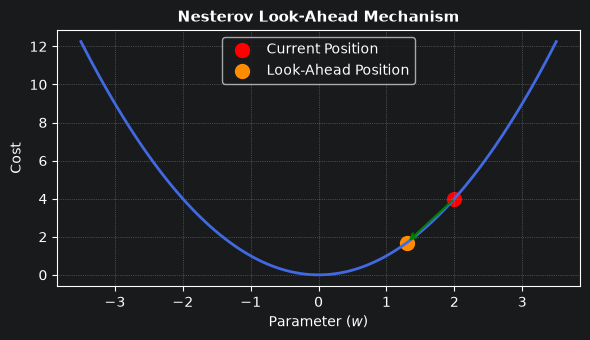

In [3]:
import numpy as np
import matplotlib.pyplot as plt

w = np.linspace(-3.5, 3.5, 100)
plt.figure(figsize=(6, 3.5))
plt.plot(w, w**2, color='royalblue', linewidth=2)
plt.scatter([2.0], [4.0], color='red', s=100, label="Current Position")
plt.scatter([1.3], [1.69], color='darkorange', s=100, label="Look-Ahead Position")
plt.annotate('', xy=(1.3, 1.69), xytext=(2.0, 4.0), arrowprops=dict(arrowstyle="->", lw=1.5, color='green'))

plt.title("Nesterov Look-Ahead Mechanism", fontsize=11, fontweight='bold')
plt.xlabel("Parameter ($w$)")
plt.ylabel("Cost")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 4. AdaGrad (Adaptive Gradient Algorithm)
* Definition: An optimizer that scales learning rates individually for each parameter based on the historical sum of squared gradients.
* Use Cases:
    * Sparse data problems like text classification and natural language processing.
* Pros:
    * Eliminates the need to manually tune the learning rate for frequent versus rare features.
* Cons:
    * The accumulated squared gradients grow indefinitely, causing the effective learning rate to shrink to zero prematurely.

### Visualizing AdaGrad Step Decay

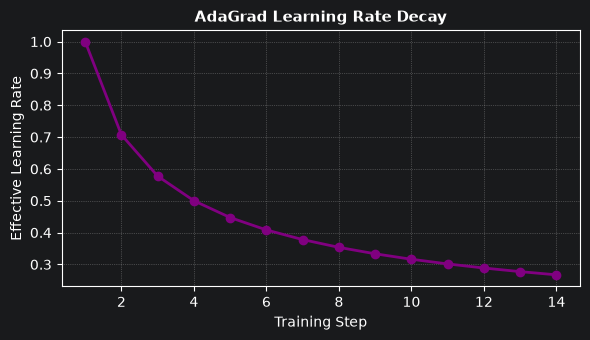

In [4]:
import numpy as np
import matplotlib.pyplot as plt

steps = np.arange(1, 15)
# Effective learning rate scales down inversely with historical sum
lr_decay = 1.0 / np.sqrt(steps)

plt.figure(figsize=(6, 3.5))
plt.plot(steps, lr_decay, marker='o', color='purple', linewidth=2)
plt.title("AdaGrad Learning Rate Decay", fontsize=11, fontweight='bold')
plt.xlabel("Training Step")
plt.ylabel("Effective Learning Rate")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 5. RMSProp (Root Mean Square Propagation)
* Definition: An adaptive learning rate method that uses an exponentially decaying average of squared gradients to restrict memory history.
* Use Cases:
    * Recurrent Neural Networks (RNNs) and non-stationary non-convex optimization problems.
* Pros:
    * Fixes AdaGrad’s aggressive learning rate decay by discarding old historical gradient squares.
* Cons:
    * Still relies on a user-defined global learning rate hyperparameter.

### Visualizing RMSProp Bounded Decay

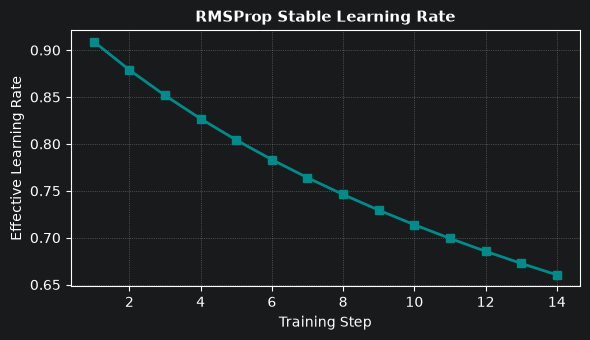

In [7]:
import numpy as np
import matplotlib.pyplot as plt

steps = np.arange(1, 15)
# RMSprop maintains a moving average, stabilizing decay
rmsprop_rate = 1.0 / (np.sqrt(np.linspace(1, 2, len(steps))) + 0.1)

plt.figure(figsize=(6, 3.5))
plt.plot(steps, rmsprop_rate, marker='s', color='darkcyan', linewidth=2)
plt.title("RMSProp Stable Learning Rate", fontsize=11, fontweight='bold')
plt.xlabel("Training Step")
plt.ylabel("Effective Learning Rate")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 6. Adam (Adaptive Moment Estimation)
* Definition: Combines the principles of both Momentum (first moment, mean) and RMSProp (second moment, uncentered variance).
* Use Cases:
    * The default general-purpose industry standard optimizer for deep learning.
* Pros:
    * Fast convergence, handles sparse gradients well, and is robust across diverse architectures.
* Cons:
    * Can occasionally generalize worse than well-tuned SGD on specific image classification tasks.

### Visualizing Adam Optimization Convergence

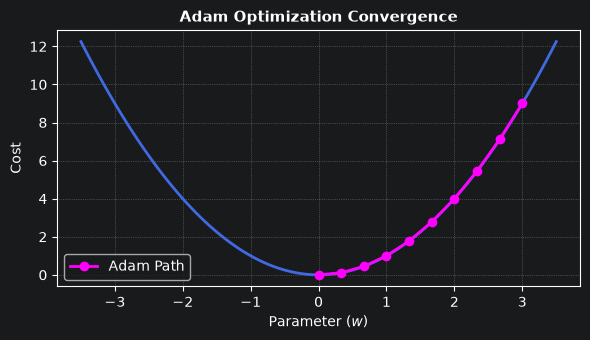

In [8]:
import numpy as np
import matplotlib.pyplot as plt

steps_w = np.linspace(3, 0, 10)
steps_cost = steps_w**2

plt.figure(figsize=(6, 3.5))
w = np.linspace(-3.5, 3.5, 100)
plt.plot(w, w**2, color='royalblue', linewidth=2)
plt.plot(steps_w, steps_cost, marker='o', color='magenta', linewidth=2, label="Adam Path")
plt.title("Adam Optimization Convergence", fontsize=11, fontweight='bold')
plt.xlabel("Parameter ($w$)")
plt.ylabel("Cost")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 7. AdamW (Adam with Decoupled Weight Decay)
* Definition: A variant of Adam that decouples L2 regularization (weight decay) directly from the gradient update calculations.
* Use Cases:
    * Training large transformers and deep architectures where standard Adam regularization fails.
* Pros:
    * Results in vastly superior regularization control and improved generalization performance.
* Cons:
    * Requires tuning an extra weight decay hyperparameter.

### Visualizing Adam vs. AdamW Regularization Impact

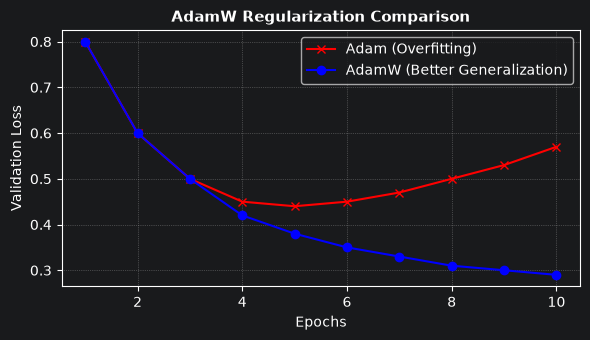

In [9]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 11)
# Simulating better validation loss reduction with AdamW
val_loss_adam = np.array([0.8, 0.6, 0.5, 0.45, 0.44, 0.45, 0.47, 0.50, 0.53, 0.57]) # Overfitting
val_loss_adamw = np.array([0.8, 0.6, 0.5, 0.42, 0.38, 0.35, 0.33, 0.31, 0.30, 0.29]) # Stable generalization

plt.figure(figsize=(6, 3.5))
plt.plot(epochs, val_loss_adam, marker='x', color='red', label="Adam (Overfitting)")
plt.plot(epochs, val_loss_adamw, marker='o', color='blue', label="AdamW (Better Generalization)")
plt.title("AdamW Regularization Comparison", fontsize=11, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Lion (Evolved Sign Momentum)
* Definition: An optimizer discovered via automated program search that uses the sign of the gradient rather than its magnitude for updates.
* Use Cases:
    * Large-scale vision transformers, language models, and high-performance pre-training.
* Pros:
    * Uses less memory than Adam (stores only momentum, not variance) and accelerates training speed.
* Cons:
    * Relatively new, requiring careful tuning of learning rates (often smaller than Adam's).

### Visualizing Lion Sign-Based Update Concept

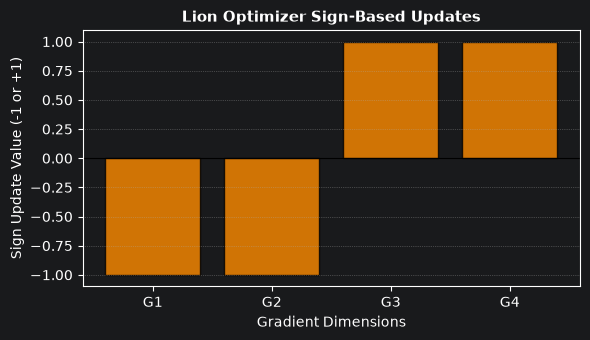

In [10]:
import numpy as np
import matplotlib.pyplot as plt

gradients = np.array([-2.5, -1.0, 0.5, 3.2])
# Lion takes only the sign: -1 or +1
lion_updates = np.sign(gradients)

plt.figure(figsize=(6, 3.5))
plt.bar(['G1', 'G2', 'G3', 'G4'], lion_updates, color='darkorange', alpha=0.8, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Lion Optimizer Sign-Based Updates", fontsize=11, fontweight='bold')
plt.xlabel("Gradient Dimensions")
plt.ylabel("Sign Update Value (-1 or +1)")
plt.grid(True, axis='y', linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()